In [27]:
import pandas as pd

# שמות עמודות תקניים ל-CMAPSS
columns = (
    ['engine_id', 'cycle'] +
    [f'op_setting_{i}' for i in range(1, 4)] +
    [f'sensor_{i}' for i in range(1, 22)]
)

path = '/kaggle/input/cmapss-jet-engine-simulated-data/train_FD001.txt'

# קריאה נכונה לקבצים עם הרבה רווחים
df = pd.read_csv(path, delim_whitespace=True, header=None)

# בדיקה כמה עמודות באמת נקראו
print("n_cols:", df.shape[1])

# אם נקראו בדיוק 26 עמודות — אפשר לשים שמות
if df.shape[1] == len(columns):
    df.columns = columns
else:
    # במקרה חריג: נחתוך לעמודות הראשונות ונשים שמות
    df = df.iloc[:, :len(columns)]
    df.columns = columns

df.head()


n_cols: 26


/tmp/ipykernel_55/931524686.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, header=None)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [28]:
df.info()
df.describe().T.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   engine_id     20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.00,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.00,156.0000,362.0000
op_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.00,0.0015,0.0087
op_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.00,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.00,100.0000,100.0000
sensor_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.67,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.64,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.10,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.04,1414.5550,1441.4900
sensor_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.62,14.6200,14.6200


<Axes: title={'center': 'Sensor behavior over time – Engine 1'}, xlabel='cycle'>

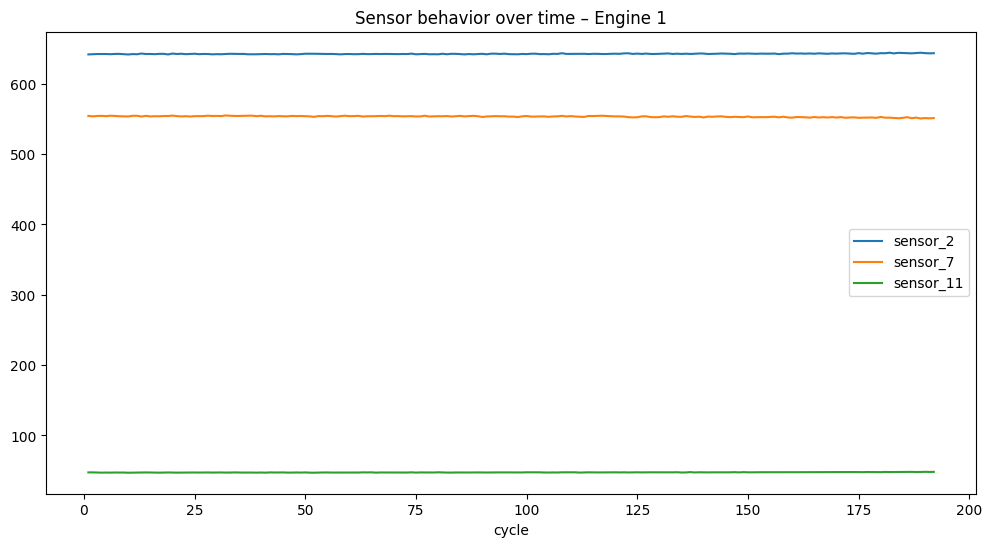

In [29]:
engine_example = df[df['engine_id'] == 1]

engine_example[['cycle', 'sensor_2', 'sensor_7', 'sensor_11']].set_index('cycle').plot(
    figsize=(12, 6),
    title='Sensor behavior over time – Engine 1'
)


In [30]:
sensor_cols = [c for c in df.columns if c.startswith('sensor')]

sensor_variance = df[sensor_cols].var().sort_values()

sensor_variance.tail(10)


sensor_20      0.032669
sensor_11      0.071336
sensor_2       0.250053
sensor_12      0.543985
sensor_7       0.783388
sensor_17      2.398667
sensor_3      37.590994
sensor_4      81.010886
sensor_14    363.900490
sensor_9     487.653568
dtype: float64

In [31]:
selected_sensors = ['sensor_20', 'sensor_11', 'sensor_2', 'sensor_12', 'sensor_7']

In [32]:
df['life_fraction'] = df.groupby('engine_id')['cycle'].transform(
    lambda x: x / x.max()
)

normal_df = df[df['life_fraction'] <= 0.3]
degraded_df = df[df['life_fraction'] >= 0.8]

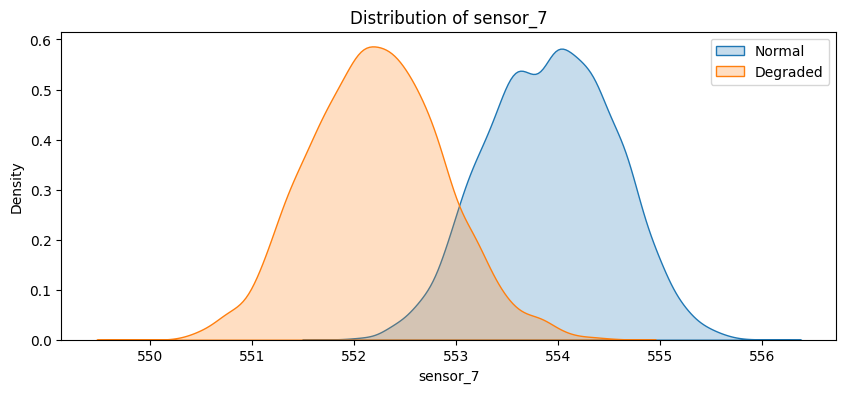

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sensor = 'sensor_7'

plt.figure(figsize=(10,4))
sns.kdeplot(normal_df[sensor], label='Normal', fill=True)
sns.kdeplot(degraded_df[sensor], label='Degraded', fill=True)
plt.title(f'Distribution of {sensor}')
plt.legend()
plt.show()


In [34]:
sensor = 'sensor_7'


In [35]:
normal_df = df[df['life_fraction'] <= 0.3]
mean_normal = normal_df[sensor].mean()
std_normal  = normal_df[sensor].std()

mean_normal, std_normal


(np.float64(553.9331038411459), 0.6216913215247667)

In [36]:
df['z_score'] = (df[sensor] - mean_normal) / std_normal
df['anomaly_rule'] = (df['z_score'].abs() > 3).astype(int)


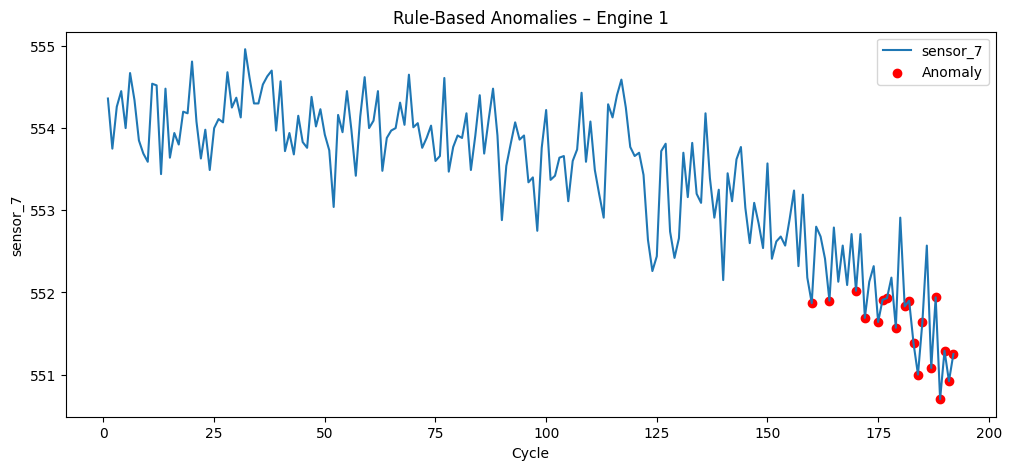

In [37]:
import matplotlib.pyplot as plt

engine_id = 1
engine_df = df[df['engine_id'] == engine_id]

plt.figure(figsize=(12,5))
plt.plot(engine_df['cycle'], engine_df[sensor], label=sensor)
plt.scatter(
    engine_df.loc[engine_df['anomaly_rule'] == 1, 'cycle'],
    engine_df.loc[engine_df['anomaly_rule'] == 1, sensor],
    color='red', label='Anomaly'
)
plt.title(f'Rule-Based Anomalies – Engine {engine_id}')
plt.xlabel('Cycle')
plt.ylabel(sensor)
plt.legend()
plt.show()


In [38]:
window = 20

df['rolling_mean'] = df.groupby('engine_id')[sensor].transform(
    lambda x: x.rolling(window, min_periods=window).mean()
)

df['rolling_std'] = df.groupby('engine_id')[sensor].transform(
    lambda x: x.rolling(window, min_periods=window).std()
)

df['rolling_z'] = (df[sensor] - df['rolling_mean']) / df['rolling_std']

df['anomaly_rule_rolling'] = (df['rolling_z'].abs() > 3).astype(int)


In [39]:
df['is_degraded'] = (df['life_fraction'] >= 0.8).astype(int)
df.head(30)

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_20,sensor_21,life_fraction,z_score,anomaly_rule,rolling_mean,rolling_std,rolling_z,anomaly_rule_rolling,is_degraded
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,39.06,23.4190,0.005208,0.686669,0,NaN,NaN,NaN,0,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,39.00,23.4236,0.010417,-0.294525,0,NaN,NaN,NaN,0,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,38.95,23.3442,0.015625,0.525817,0,NaN,NaN,NaN,0,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,38.88,23.3739,0.020833,0.831435,0,NaN,NaN,NaN,0,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,38.90,23.4044,0.026042,0.107603,0,NaN,NaN,NaN,0,0
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,38.98,23.3669,0.031250,1.185309,0,NaN,NaN,NaN,0,0
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,39.10,23.3774,0.036458,0.654499,0,NaN,NaN,NaN,0,0
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,38.97,23.3106,0.041667,-0.133674,0,NaN,NaN,NaN,0,0
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,39.05,23.4066,0.046875,-0.391036,0,NaN,NaN,NaN,0,0
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,38.95,23.4694,0.052083,-0.551888,0,NaN,NaN,NaN,0,0


In [40]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(df['is_degraded'], df['anomaly_rule'])
recall    = recall_score(df['is_degraded'], df['anomaly_rule'])

precision, recall


(0.9399025446670276, 0.41471571906354515)

# I implemented a rule-based anomaly detection baseline using early-life statistics and rolling Z-score and evaluated it's ability to detect degredation

In [41]:
selected_sensors = ['sensor_2', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']
window = 20

features = []

for s in selected_sensors:
    df[f'{s}_mean'] = df.groupby('engine_id')[s].transform(
        lambda x: x.rolling(window, min_periods=window).mean()
    )
    df[f'{s}_std'] = df.groupby('engine_id')[s].transform(
        lambda x: x.rolling(window, min_periods=window).std()
    )
    features.extend([f'{s}_mean', f'{s}_std'])


In [42]:
from sklearn.ensemble import IsolationForest

train_df = df[df['life_fraction'] <= 0.3].dropna()
X_train = train_df[features]


In [43]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.1,
    random_state=42
)

iso.fit(X_train)


IsolationForest(contamination=0.1, n_estimators=200, random_state=42)

In [44]:
df_valid = df.dropna(subset=features).copy()


# sklearn מחזיר -1 כאנומליה, 1 כנורמלי
df_valid.loc[:, 'iso_pred'] = iso.predict(df_valid[features])
df_valid.loc[:, 'iso_anomaly'] = (df_valid['iso_pred'] == -1).astype(int)

In [45]:
from sklearn.metrics import precision_score, recall_score

precision_iso = precision_score(df_valid['is_degraded'], df_valid['iso_anomaly'])
recall_iso    = recall_score(df_valid['is_degraded'], df_valid['iso_anomaly'])

precision_iso, recall_iso


(0.5360686511128989, 0.9550883898709985)

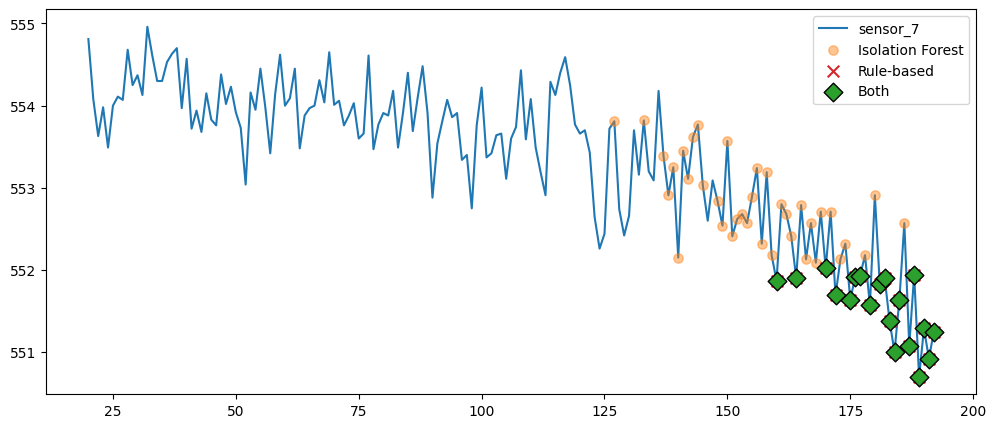

In [46]:
import matplotlib.pyplot as plt

engine_id = 1
sensor = 'sensor_7'
rule_col = 'anomaly_rule'   # כפי שאמרת

eng = df_valid[df_valid['engine_id'] == engine_id].copy()

iso_m  = eng['iso_anomaly'] == 1
rule_m = eng[rule_col] == 1
both_m = iso_m & rule_m

COLORS = {
    'signal': '#1f77b4',      # כחול – קו הסנסור
    'iso':    '#ff7f0e',      # כתום – Isolation Forest
    'rule':   '#d62728',      # אדום – Rule-based
    'both':   '#2ca02c'       # ירוק – חפיפה
}

plt.figure(figsize=(12,5))

plt.plot(
    eng['cycle'], eng[sensor],
    color=COLORS['signal'],
    label=sensor,
    linewidth=1.5
)

plt.scatter(
    eng.loc[iso_m, 'cycle'],
    eng.loc[iso_m, sensor],
    color=COLORS['iso'],
    label='Isolation Forest',
    s=45,
    alpha=0.45,
    zorder=3
)

plt.scatter(
    eng.loc[rule_m, 'cycle'],
    eng.loc[rule_m, sensor],
    color=COLORS['rule'],
    label='Rule-based',
    marker='x',
    s=70,
    zorder=4
)

plt.scatter(
    eng.loc[both_m, 'cycle'],
    eng.loc[both_m, sensor],
    color=COLORS['both'],
    label='Both',
    marker='D',
    s=90,
    edgecolors='black',
    linewidths=1.0,
    zorder=5
)
plt.savefig("final_figure.png", dpi=150, bbox_inches="tight")
plt.legend()
plt.show()


In [47]:
# אם rule-based קיים ב-df אבל לא ב-df_valid:
if 'anomaly_rule_rolling' in df.columns and 'anomaly_rule_rolling' not in df_valid.columns:
    df_valid = df_valid.join(df[['engine_id','cycle','anomaly_rule_rolling']].set_index(['engine_id','cycle']),
                             on=['engine_id','cycle'])
df_valid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18731 entries, 19 to 20630
Data columns (total 46 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   engine_id             18731 non-null  int64  
 1   cycle                 18731 non-null  int64  
 2   op_setting_1          18731 non-null  float64
 3   op_setting_2          18731 non-null  float64
 4   op_setting_3          18731 non-null  float64
 5   sensor_1              18731 non-null  float64
 6   sensor_2              18731 non-null  float64
 7   sensor_3              18731 non-null  float64
 8   sensor_4              18731 non-null  float64
 9   sensor_5              18731 non-null  float64
 10  sensor_6              18731 non-null  float64
 11  sensor_7              18731 non-null  float64
 12  sensor_8              18731 non-null  float64
 13  sensor_9              18731 non-null  float64
 14  sensor_10             18731 non-null  float64
 15  sensor_11             1


# Now we apply the model to each engine separately.

At this stage, the model is evaluated on entire engine lifecycles rather than on mixed data from the same engines used during training. Each engine represents a complete time-series with its own baseline behavior and degradation pattern.Training and evaluating on the same engine can lead to overly optimistic results, as the model may implicitly adapt to engine-specific characteristics. Therefore, an engine-level split is introduced during tuning: the model is trained on early-life data from a subset of engines and evaluated on previously unseen engines. This ensures that performance metrics reflect the model’s ability to generalize to new engines, which is the realistic deployment scenario for condition monitoring systems.


In [48]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score

RANDOM_STATE = 42

# 1) מוודא שיש life_fraction + is_degraded
if 'life_fraction' not in df.columns:
    df['life_fraction'] = df.groupby('engine_id')['cycle'].transform(lambda x: x / x.max())
if 'is_degraded' not in df.columns:
    df['is_degraded'] = (df['life_fraction'] >= 0.8).astype(int)

# 2) df_valid עם features (אין NaNs)
df_valid = df.dropna(subset=features).copy()

# 3) split לפי מנועים
engine_ids = df_valid['engine_id'].unique()
rng = np.random.RandomState(RANDOM_STATE)
rng.shuffle(engine_ids)

split = int(0.8 * len(engine_ids))
train_engines = set(engine_ids[:split])
eval_engines  = set(engine_ids[split:])

train_df = df_valid[df_valid['engine_id'].isin(train_engines)]
eval_df  = df_valid[df_valid['engine_id'].isin(eval_engines)]

# 4) אימון על early-life בלבד
train_normal = train_df[train_df['life_fraction'] <= 0.3]
X_train = train_normal[features]

X_eval = eval_df[features]
y_eval = eval_df['is_degraded'].values

# 5) grid ממוקד
grid = []
for contamination in [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20]:
    for n_estimators in [200, 500]:
        for max_features in [0.4,0.5,0.6, 0.8, 1.0]:
            iso = IsolationForest(
                n_estimators=n_estimators,
                contamination=contamination,
                max_features=max_features,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
            iso.fit(X_train)

            pred = iso.predict(X_eval)   # -1 anomaly
            yhat = (pred == -1).astype(int)

            p = precision_score(y_eval, yhat, zero_division=0)
            r = recall_score(y_eval, yhat, zero_division=0)
            f1 = f1_score(y_eval, yhat, zero_division=0)

            grid.append({
                "contamination": contamination,
                "n_estimators": n_estimators,
                "max_features": max_features,
                "precision": p,
                "recall": r,
                "f1": f1,
                "anomaly_rate": yhat.mean()  # כמה אחוז מסומן אנומליה
            })

res = pd.DataFrame(grid)

# 6) Recall גבוה, עם Precision מינימלי סביר
PREC_MIN = 0.40  
candidates = res[res["precision"] >= PREC_MIN].sort_values(["recall", "precision"], ascending=False)

candidates.head(10)


,contamination,n_estimators,max_features,precision,recall,f1,anomaly_rate
87,0.20,500,0.6,0.467804,0.978136,0.632911,0.464587
88,0.20,500,0.8,0.466776,0.978136,0.631970,0.465610
86,0.20,500,0.5,0.462459,0.978136,0.628001,0.469957
83,0.20,200,0.8,0.464658,0.975834,0.629547,0.466633
85,0.20,500,0.4,0.462882,0.975834,0.627916,0.468422
84,0.20,200,1.0,0.461371,0.975834,0.626524,0.469957
89,0.20,500,1.0,0.460619,0.975834,0.625830,0.470724
82,0.20,200,0.6,0.468214,0.974684,0.632562,0.462542
77,0.15,500,0.6,0.510561,0.973533,0.669834,0.423677
78,0.15,500,0.8,0.508413,0.973533,0.667983,0.425467


Contamination controls how aggressive the detector is, max_features affects tree diversity and generalization, F1 summarizes the precision–recall balance, and anomaly_rate reflects the operational cost of false alarms.

**Among the tuned models, a contamination level of 0.15 provided the best balance for a safety-oriented objective.
It achieved near-maximal recall while significantly reducing the anomaly rate compared to more aggressive configurations.**

In [49]:
summary = pd.DataFrame([
    {
        "Method": "Rule-based (Z-score)",
        "Precision": 0.94,
        "Recall": 0.41,
        "Notes": "Conservative, highly interpretable"
    },
    {
        "Method": "Isolation Forest (tuned)",
        "Precision": 0.51,
        "Recall": 0.97,
        "Notes": "Early detection, higher false-alarm rate"
    }
])

summary


,Method,Precision,Recall,Notes
0,Rule-based (Z-score),0.94,0.41,"Conservative, highly interpretable"
1,Isolation Forest (tuned),0.51,0.97,"Early detection, higher false-alarm rate"


**Conclusions**

* A rule-based Z-score detector achieved very high precision but failed to detect early-stage degradation.

* A tuned Isolation Forest significantly improved recall by identifying subtle multivariate changes in sensor behavior.

* Higher recall came at the cost of increased false positives, highlighting the trade-off between conservative and safety-oriented detection.

* Engine-level splitting was essential to ensure realistic generalization to unseen engines.

* Model selection depends on system priorities: early detection vs. alert fatigue.